Step 1. IMPORTS & DEVICE CHECKS

In [1]:
import torch
import cv2
import librosa
import numpy as np
import pandas as pd

import moviepy          # top-level moviepy package
from moviepy import VideoFileClip

import mediapipe as mp
from sklearn.metrics import classification_report, confusion_matrix
from tqdm import tqdm

print("Packages imported successfully")

print("\nPython executable:", __import__("sys").executable)

# Torch / GPU info
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

# Library versions
print("\nOpenCV version:", cv2.__version__)
print("Librosa version:", librosa.__version__)
print("MoviePy version:", moviepy.__version__)
print("Mediapipe version:", mp.__version__)


Packages imported successfully

Python executable: D:\Software\Anaconda3\envs\deepfake\python.exe
Torch version: 2.5.1
CUDA available: True
GPU: NVIDIA GeForce RTX 4060 Laptop GPU

OpenCV version: 4.11.0
Librosa version: 0.11.0
MoviePy version: 2.1.2
Mediapipe version: 0.10.9


In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)


Using device: cuda


Step 2. CONSTANTS

In [3]:
AUDIO_SR = 16000
AUDIO_LEN = 4.0
N_MFCC = 40
N_MELS = 64
TARGET_T = 126

NUM_FRAMES = 16
IMG_SIZE = 112

N_CLASSES = 4


Step 3: LOAD CSV + BUILD video_path + CREATE label

3.1 Load CSV Files

In [4]:
import os
import pandas as pd

train_df = pd.read_csv("full_train_metadata.csv")
test_df  = pd.read_csv("full_test_metadata.csv")

print("Train columns:", train_df.columns.tolist())
print("Test columns :", test_df.columns.tolist())


Train columns: ['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path', 'Unnamed: 9']
Test columns : ['source', 'target1', 'target2', 'method', 'category', 'type', 'race', 'gender', 'path', 'Unnamed: 9']


3.2 Build video_path

In [5]:
ROOT_DIR = "./FakeAVCeleb_v1.2"

def build_video_path(row):
    folder = str(row["Unnamed: 9"]).strip().replace("\\", "/")

    # remove FakeAVCeleb/ prefix if present
    if folder.startswith("FakeAVCeleb/"):
        folder = folder.replace("FakeAVCeleb/", "")

    folder = folder.replace("/", os.sep)
    filename = str(row["path"]).strip()

    return os.path.join(ROOT_DIR, folder, filename)


In [6]:
train_df["video_path"] = train_df.apply(build_video_path, axis=1)
test_df["video_path"]  = test_df.apply(build_video_path, axis=1)


3.3 Verify Paths Exist

In [7]:
print("Sample TRAIN paths:")
for p in train_df["video_path"].head(5):
    print(p, "| exists:", os.path.exists(p))

print("\nSample TEST paths:")
for p in test_df["video_path"].head(5):
    print(p, "| exists:", os.path.exists(p))


Sample TRAIN paths:
./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\Asian (South)\women\id07236\00143_id07689_wavtolip.mp4 | exists: True
./FakeAVCeleb_v1.2\FakeVideo-RealAudio\Caucasian (American)\women\id00261\00048_id00261_wavtolip.mp4 | exists: True
./FakeAVCeleb_v1.2\FakeVideo-RealAudio\Caucasian (American)\women\id00458\00072_id00618__TwV2SmUIlY.mp4 | exists: True
./FakeAVCeleb_v1.2\FakeVideo-RealAudio\Asian (South)\women\id04070\00072_id04583_wavtolip.mp4 | exists: True
./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\African\men\id00366\00118_id01920_w9C_knCPD94_id01170_wavtolip.mp4 | exists: True

Sample TEST paths:
./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\Asian (South)\men\id08314\00028_id04601_wavtolip.mp4 | exists: True
./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\Asian (South)\men\id07163\00141_id04526_wavtolip.mp4 | exists: True
./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\Caucasian (American)\women\id00383\00171_id00180_wavtolip.mp4 | exists: True
./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\African\women\id0

3.4 Create label from Folder Name

In [8]:
def label_from_path(p):
    if "RealVideo-RealAudio" in p:
        return 0  # RV-RA
    if "FakeVideo-RealAudio" in p:
        return 1  # FV-RA
    if "RealVideo-FakeAudio" in p:
        return 2  # RV-FA
    if "FakeVideo-FakeAudio" in p:
        return 3  # FV-FA
    return -1


In [9]:
train_df["label"] = train_df["video_path"].astype(str).apply(label_from_path)
test_df["label"]  = test_df["video_path"].astype(str).apply(label_from_path)


3.5 Remove Invalid Rows

In [10]:
train_df = train_df[train_df["label"] != -1].reset_index(drop=True)
test_df  = test_df[test_df["label"]  != -1].reset_index(drop=True)


3.6 Final Verification

In [11]:
LABEL_MAP = {
    0: "RV-RA ",
    1: "FV-RA ",
    2: "RV-FA ",
    3: "FV-FA "
}

# ---- TRAIN SET ----
print("\nTRAIN LABEL DISTRIBUTION:")
for label_id, count in train_df["label"].value_counts().sort_index().items():
    print(f"{label_id}  →  {LABEL_MAP[label_id]} : {count}")

# ---- TEST SET ----
print("\nTEST LABEL DISTRIBUTION:")
for label_id, count in test_df["label"].value_counts().sort_index().items():
    print(f"{label_id}  →  {LABEL_MAP[label_id]} : {count}")

# ---- DATASET SIZES ----
print("\nDATASET SIZES:")
print("Train size :", len(train_df))
print("Test size  :", len(test_df))

train_df["label_name"] = train_df["label"].map(LABEL_MAP)
test_df["label_name"]  = test_df["label"].map(LABEL_MAP)

print("\nSAMPLE ROWS (Train):")
display(train_df[["video_path", "label", "label_name"]].head())


TRAIN LABEL DISTRIBUTION:
0  →  RV-RA  : 350
1  →  FV-RA  : 6796
2  →  RV-FA  : 350
3  →  FV-FA  : 7600

TEST LABEL DISTRIBUTION:
0  →  RV-RA  : 150
1  →  FV-RA  : 2913
2  →  RV-FA  : 150
3  →  FV-FA  : 3257

DATASET SIZES:
Train size : 15096
Test size  : 6470

SAMPLE ROWS (Train):


,video_path,label,label_name
0,./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\Asian (...,3,FV-FA
1,./FakeAVCeleb_v1.2\FakeVideo-RealAudio\Caucasi...,1,FV-RA
2,./FakeAVCeleb_v1.2\FakeVideo-RealAudio\Caucasi...,1,FV-RA
3,./FakeAVCeleb_v1.2\FakeVideo-RealAudio\Asian (...,1,FV-RA
4,./FakeAVCeleb_v1.2\FakeVideo-FakeAudio\African...,3,FV-FA


STEP 4: AUDIO EXTRACTION & FEATURE GENERATION

4.1: Audio Parameters

In [12]:
AUDIO_SR   = 16000        # sampling rate
AUDIO_LEN = 4.0          # seconds
N_MFCC    = 40
N_MELS    = 64
TARGET_T  = 126           # fixed time steps

4.2: Extract Audio from Video

In [13]:
#Load audio waveform from video
import subprocess
import tempfile
import librosa
import numpy as np
import os

def load_audio_from_video(video_path):
    """
    Extract mono audio from video using ffmpeg
    Returns float32 waveform of fixed length
    """
    try:
        tmp_wav = tempfile.mktemp(suffix=".wav")

        cmd = [
            "ffmpeg", "-y",
            "-i", video_path,
            "-vn",            # no video
            "-ac", "1",       # mono
            "-ar", str(AUDIO_SR),
            tmp_wav
        ]

        subprocess.run(
            cmd,
            stdout=subprocess.DEVNULL,
            stderr=subprocess.DEVNULL
        )

        y, _ = librosa.load(
            tmp_wav,
            sr=AUDIO_SR,
            duration=AUDIO_LEN
        )

        os.remove(tmp_wav)
        return y.astype(np.float32)

    except Exception as e:
        # fallback: silence
        return np.zeros(int(AUDIO_SR * AUDIO_LEN), dtype=np.float32)

4.3: Pad / Trim Helper

In [14]:
#Pad or trim features to fixed time steps
def pad_or_trim(feat, target_T):
    """
    feat: (F, T)
    return: (F, target_T)
    """
    if feat.shape[1] < target_T:
        pad = target_T - feat.shape[1]
        feat = np.pad(feat, ((0, 0), (0, pad)))
    else:
        feat = feat[:, :target_T]
    return feat

4.4: MFCC + Log-Mel Feature Extraction

In [15]:
#Extract MFCC and Log-Mel features

def extract_audio_features(waveform):
    """
    Input: raw waveform
    Output:
      mfcc  -> (1, 40, T)
      mel   -> (1, 64, T)
    """

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=waveform,
        sr=AUDIO_SR,
        n_mfcc=N_MFCC
    )

    # Mel Spectrogram
    mel = librosa.feature.melspectrogram(
        y=waveform,
        sr=AUDIO_SR,
        n_mels=N_MELS
    )
    mel = librosa.power_to_db(mel, ref=np.max)

    # Fix time dimension
    mfcc = pad_or_trim(mfcc, TARGET_T)
    mel  = pad_or_trim(mel, TARGET_T)

    # Convert to torch format later in Dataset
    mfcc = torch.tensor(mfcc, dtype=torch.float32).unsqueeze(0)
    mel  = torch.tensor(mel,  dtype=torch.float32).unsqueeze(0)

    return mfcc, mel

In [16]:
sample_path = train_df["video_path"].iloc[0]
wav = load_audio_from_video(sample_path)
mfcc, mel = extract_audio_features(wav)

print("Waveform shape:", wav.shape)
print("MFCC shape     :", mfcc.shape)  # (1, 40, 126)
print("Log-Mel shape  :", mel.shape)   # (1, 64, 126)

Waveform shape: (62464,)
MFCC shape     : torch.Size([1, 40, 126])
Log-Mel shape  : torch.Size([1, 64, 126])


4.5 VISUALIZE AUDIO FEATURES FOR ALL 4 CLASSES

In [17]:
samples = {}

for label_id in [0, 1, 2, 3]:
    sample_row = train_df[train_df["label"] == label_id].iloc[0]
    samples[label_id] = sample_row["video_path"]

LABEL_MAP = {
    0: "RV-RA ",
    1: "FV-RA ",
    2: "RV-FA ",
    3: "FV-FA "
}

In [18]:
import matplotlib.pyplot as plt
import librosa.display

def visualize_audio_features(video_path, label_name):
    # Load audio
    wav = load_audio_from_video(video_path)
    mfcc, mel = extract_audio_features(wav)

    mfcc = mfcc.squeeze(0).numpy()
    mel  = mel.squeeze(0).numpy()

    plt.figure(figsize=(12, 8))

    # Waveform 
    plt.subplot(3, 1, 1)
    librosa.display.waveshow(wav, sr=AUDIO_SR)
    plt.title(f"Waveform - {label_name}")
    plt.xlabel("Time")
    plt.ylabel("Amplitude")

    # MFCC 
    plt.subplot(3, 1, 2)
    librosa.display.specshow(mfcc, sr=AUDIO_SR, x_axis="time")
    plt.colorbar()
    plt.title("MFCC")

    # Log-Mel 
    plt.subplot(3, 1, 3)
    librosa.display.specshow(mel, sr=AUDIO_SR, x_axis="time", y_axis="mel")
    plt.colorbar()
    plt.title("Log-Mel Spectrogram")

    plt.tight_layout()
    plt.show()



Showing audio features for: RV-RA 


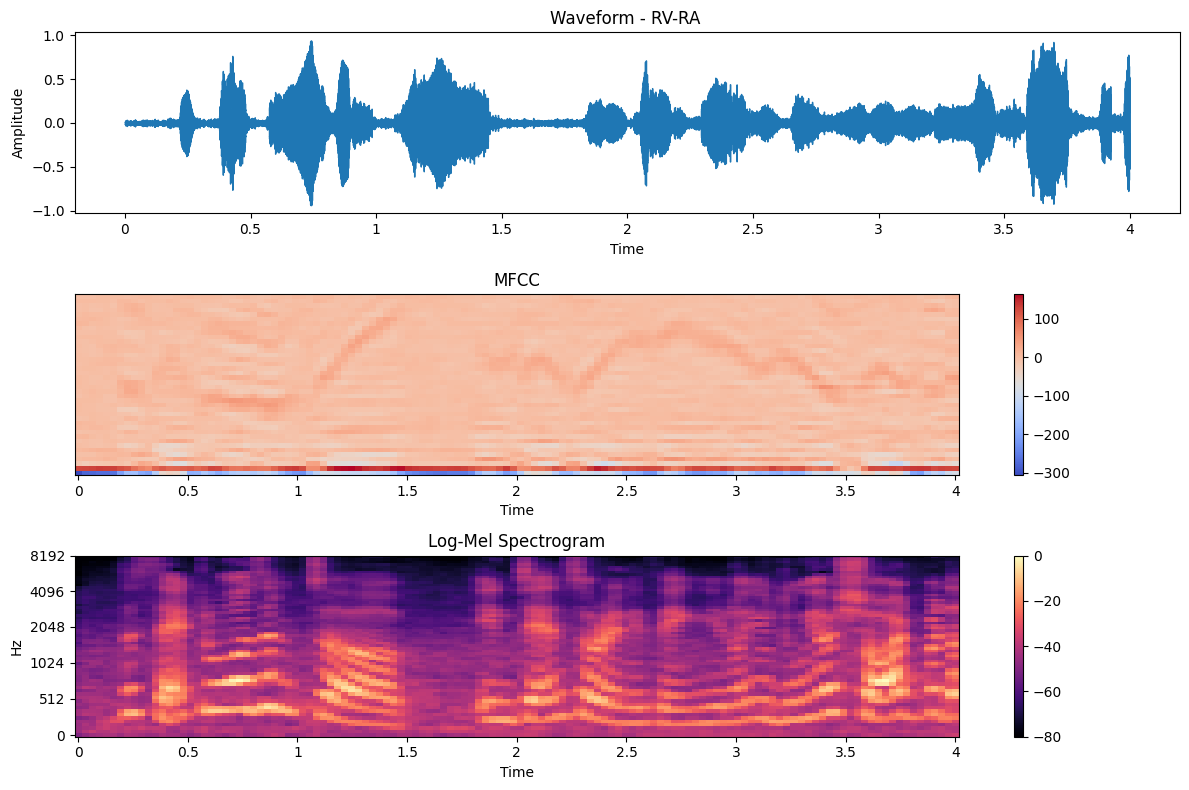


Showing audio features for: FV-RA 


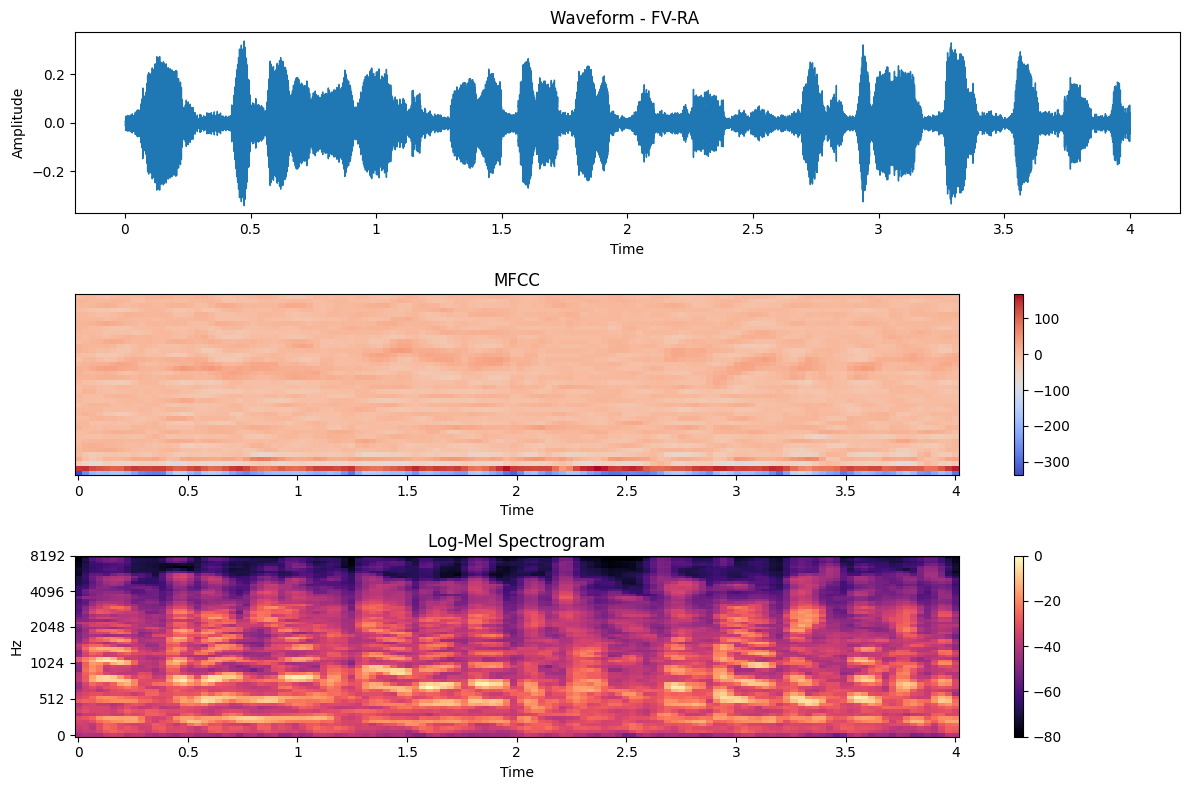


Showing audio features for: RV-FA 


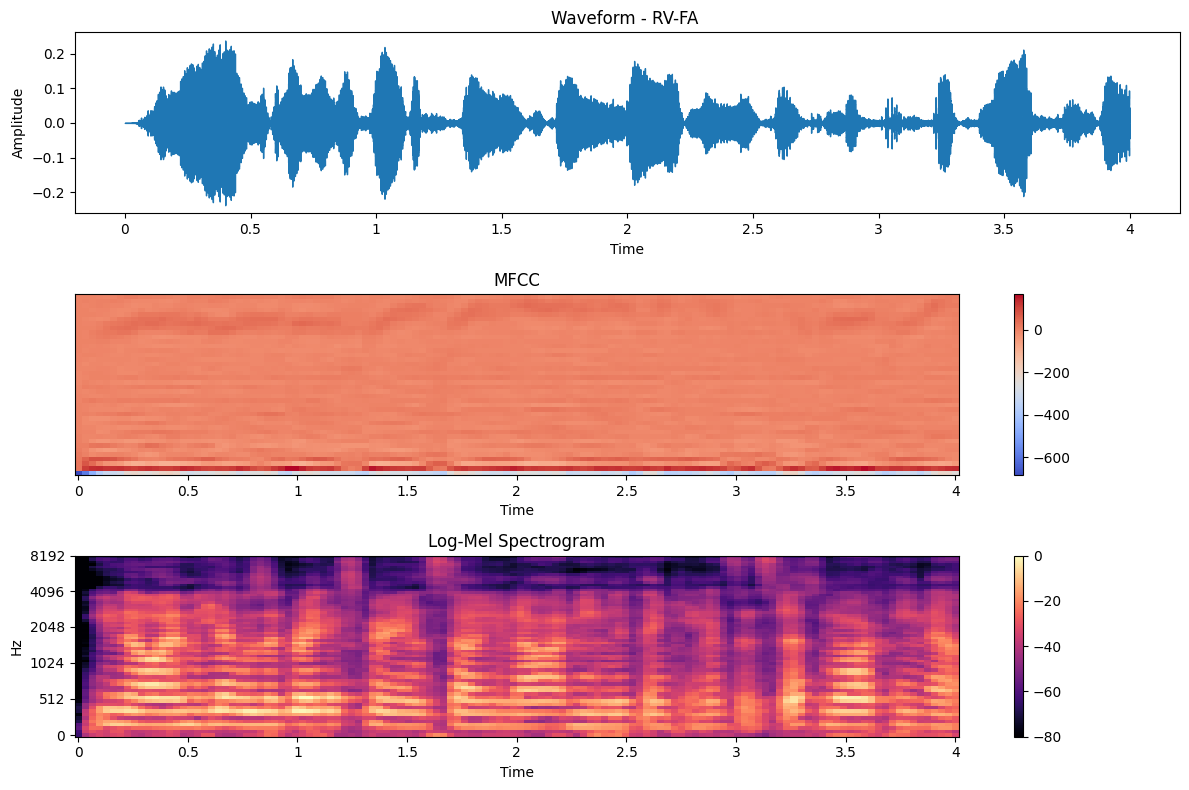


Showing audio features for: FV-FA 


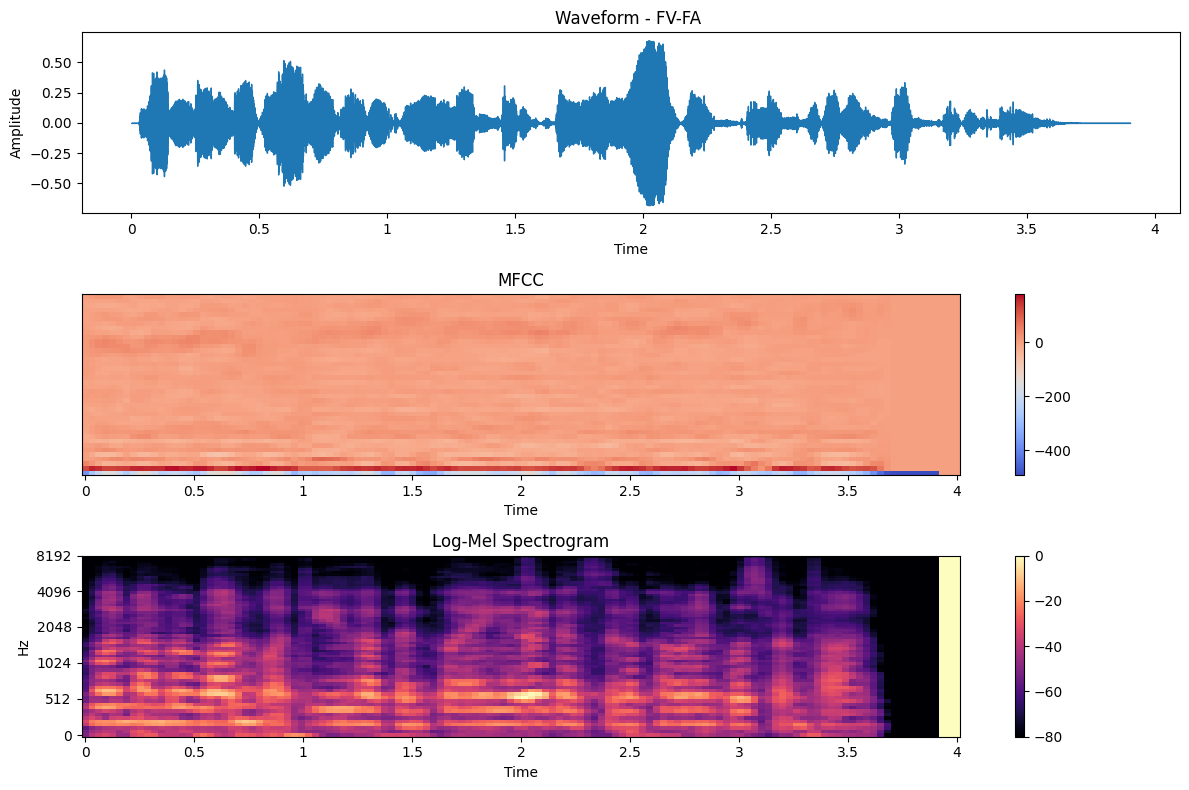

In [19]:
for label_id, video_path in samples.items():
    print(f"\nShowing audio features for: {LABEL_MAP[label_id]}")
    visualize_audio_features(video_path, LABEL_MAP[label_id])

In [20]:
"""
1 RV-RA (Real Video – Real Audio)

Waveform
Natural variation
Smooth energy changes
No sudden spikes

MFCC
Stable coefficients
Smooth transitions across time

Log-Mel
Clear harmonic bands
Natural speech frequency distribution

🧠 Represents genuine human speech.




2 FV-RA (Fake Video – Real Audio)

Waveform
Looks very similar to RV-RA (audio is real!)

MFCC
Very close to RV-RA
Minor differences only

Log-Mel
Natural frequency patterns

🧠 Audio features are real — manipulation is only in video.




3 RV-FA (Real Video – Fake Audio)

Waveform
Slightly flatter or repetitive patterns
Less natural pauses

MFCC
Reduced variation
Some coefficients look repetitive

Log-Mel
Less clear harmonic structure
Artificial smoothing visible

🧠 Audio is synthesized or altered.



4 FV-FA (Fake Video – Fake Audio)

Waveform
Most artificial looking
Repeated patterns or abrupt changes

MFCC
High similarity across time
Loss of natural dynamics

Log-Mel
Blurred frequency bands
Less energy diversity
🧠 Both modalities are manipulated.
"""

'\n1 RV-RA (Real Video – Real Audio)\n\nWaveform\nNatural variation\nSmooth energy changes\nNo sudden spikes\n\nMFCC\nStable coefficients\nSmooth transitions across time\n\nLog-Mel\nClear harmonic bands\nNatural speech frequency distribution\n\n🧠 Represents genuine human speech.\n\n\n\n\n2 FV-RA (Fake Video – Real Audio)\n\nWaveform\nLooks very similar to RV-RA (audio is real!)\n\nMFCC\nVery close to RV-RA\nMinor differences only\n\nLog-Mel\nNatural frequency patterns\n\n🧠 Audio features are real — manipulation is only in video.\n\n\n\n\n3 RV-FA (Real Video – Fake Audio)\n\nWaveform\nSlightly flatter or repetitive patterns\nLess natural pauses\n\nMFCC\nReduced variation\nSome coefficients look repetitive\n\nLog-Mel\nLess clear harmonic structure\nArtificial smoothing visible\n\n🧠 Audio is synthesized or altered.\n\n\n\n4 FV-FA (Fake Video – Fake Audio)\n\nWaveform\nMost artificial looking\nRepeated patterns or abrupt changes\n\nMFCC\nHigh similarity across time\nLoss of natural dynamic

Step 5: LIP-BASED VIDEO FRAME EXTRACTION

5.1 Video Parameters

In [21]:
#Video configuration

NUM_FRAMES = 16
IMG_SIZE   = 112

5.2: Initialize MediaPipe FaceMesh

In [22]:
import mediapipe as mp

mp_face_mesh = mp.solutions.face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
)

# Lip landmark indices (MediaPipe standard)
LIP_LANDMARKS = list(range(61, 88))

5.3: Lip Bounding Box Function

In [23]:
def get_lip_bbox(landmarks, img_w, img_h, margin=0.3):
    xs = [landmarks[i].x for i in LIP_LANDMARKS]
    ys = [landmarks[i].y for i in LIP_LANDMARKS]

    cx, cy = np.mean(xs), np.mean(ys)
    size = max(max(xs)-min(xs), max(ys)-min(ys)) * (1 + margin)

    x1 = int((cx - size/2) * img_w)
    x2 = int((cx + size/2) * img_w)
    y1 = int((cy - size/2) * img_h)
    y2 = int((cy + size/2) * img_h)

    return (
        max(0, x1),
        max(0, y1),
        min(img_w, x2),
        min(img_h, y2)
    )

5.4: Extract Lip Frames from Video

In [24]:
import cv2
import torch
import numpy as np

def extract_lip_frames(video_path):
    cap = cv2.VideoCapture(video_path)
    frames = []

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        cap.release()
        return torch.zeros(NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE)

    frame_indices = np.linspace(0, total_frames - 1, NUM_FRAMES, dtype=int)

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue

        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = mp_face_mesh.process(rgb)

        if result.multi_face_landmarks:
            lm = result.multi_face_landmarks[0].landmark
            x1, y1, x2, y2 = get_lip_bbox(lm, w, h)
            frame = frame[y1:y2, x1:x2]

        frame = cv2.resize(frame, (IMG_SIZE, IMG_SIZE))
        frame = frame.astype(np.float32) / 255.0
        frame = torch.tensor(frame).permute(2, 0, 1)  # (3,H,W)
        frames.append(frame)

    cap.release()

    if len(frames) == 0:
        return torch.zeros(NUM_FRAMES, 3, IMG_SIZE, IMG_SIZE)

    return torch.stack(frames)

5.5: Visualize Lip Frames

In [25]:
import matplotlib.pyplot as plt

def show_lip_frames(video_path, label_name, num_show=6):
    frames = extract_lip_frames(video_path)

    plt.figure(figsize=(12, 3))
    for i in range(min(num_show, frames.shape[0])):
        img = frames[i].permute(1, 2, 0).numpy()
        plt.subplot(1, num_show, i + 1)
        plt.imshow(img)
        plt.title(f"{label_name}\nFrame {i}")
        plt.axis("off")

    plt.tight_layout()
    plt.show()

5.6: Show Lip Frames for All 4 Classes

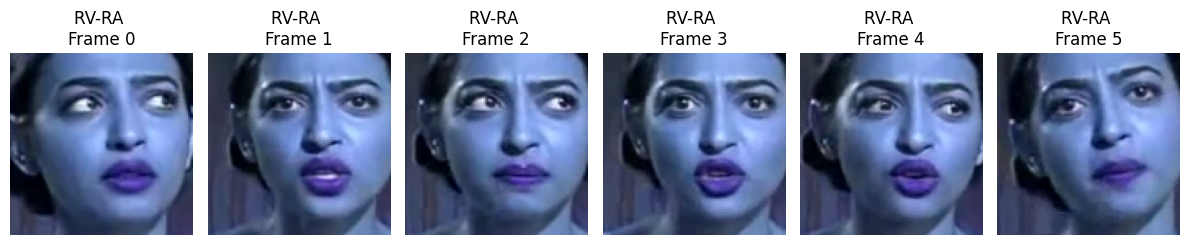

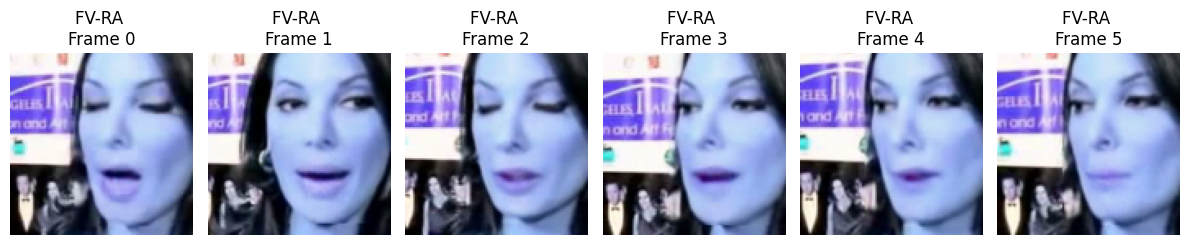

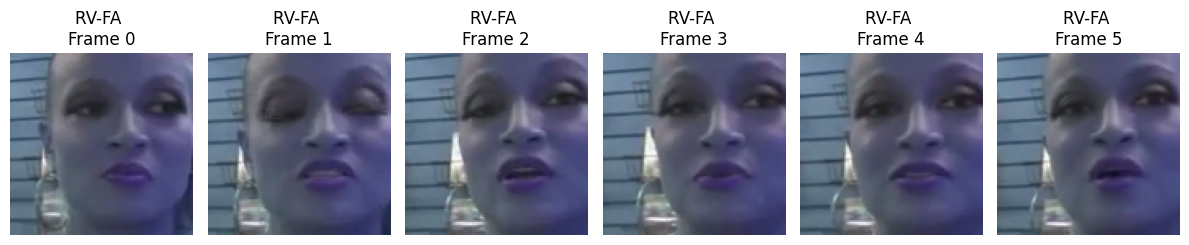

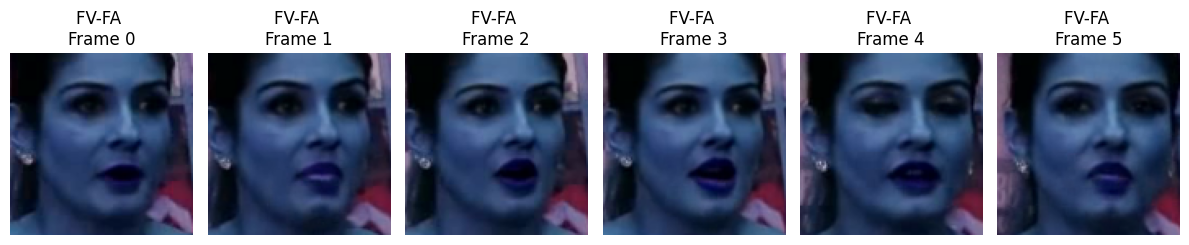

In [26]:
for label_id in [0, 1, 2, 3]:
    sample_video = train_df[train_df["label"] == label_id].iloc[0]["video_path"]
    show_lip_frames(sample_video, LABEL_MAP[label_id])

5.7.1: Function to Draw Lip Box on Frames

In [27]:
# Show lip bounding box on video frames

def show_lip_boxes(video_path, label_name, num_show=6):
    cap = cv2.VideoCapture(video_path)

    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total_frames <= 0:
        print("No frames found.")
        cap.release()
        return

    frame_indices = np.linspace(0, total_frames - 1, num_show, dtype=int)

    plt.figure(figsize=(14, 3))
    plot_idx = 1

    for idx in frame_indices:
        cap.set(cv2.CAP_PROP_POS_FRAMES, idx)
        ret, frame = cap.read()
        if not ret:
            continue

        h, w = frame.shape[:2]
        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = mp_face_mesh.process(rgb)

        # Draw lip box if face detected
        if result.multi_face_landmarks:
            landmarks = result.multi_face_landmarks[0].landmark
            x1, y1, x2, y2 = get_lip_bbox(landmarks, w, h)

            # Draw rectangle (red box)
            cv2.rectangle(
                rgb,
                (x1, y1),
                (x2, y2),
                (255, 0, 0),
                2
            )

        plt.subplot(1, num_show, plot_idx)
        plt.imshow(rgb)
        plt.title(f"{label_name}\nFrame {idx}")
        plt.axis("off")
        plot_idx += 1

    cap.release()
    plt.tight_layout()
    plt.show()


5.7.2: Show Lip Boxes for All 4 Classes

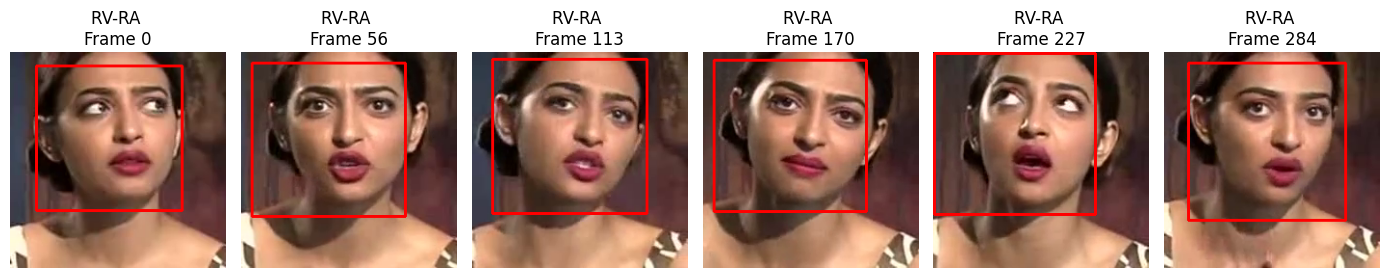

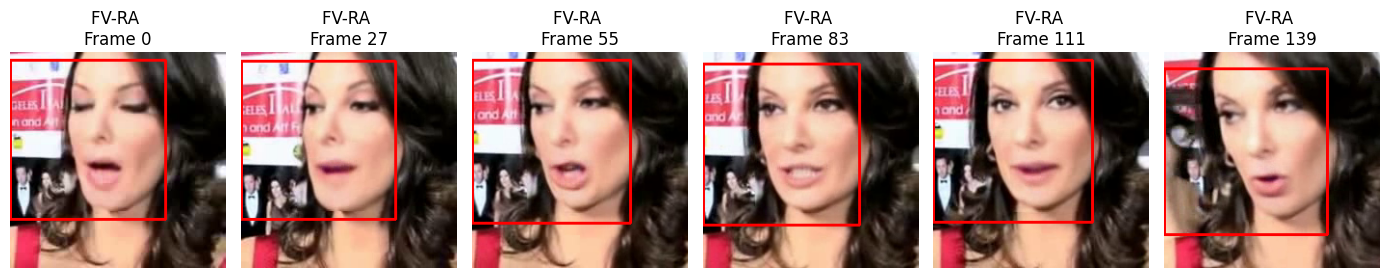

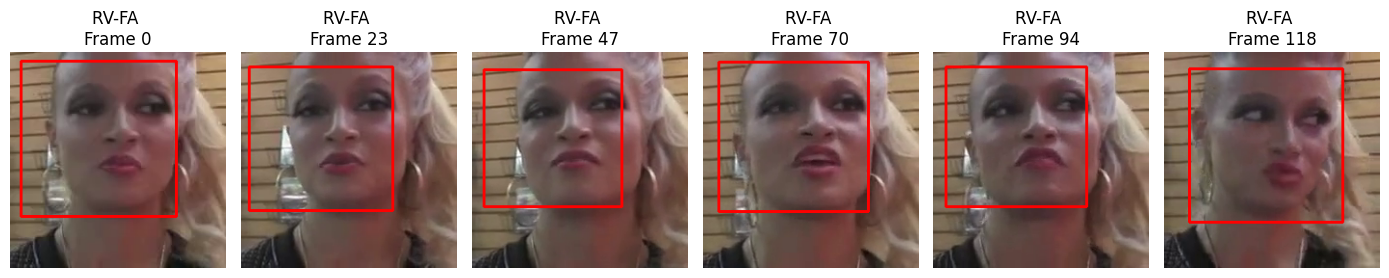

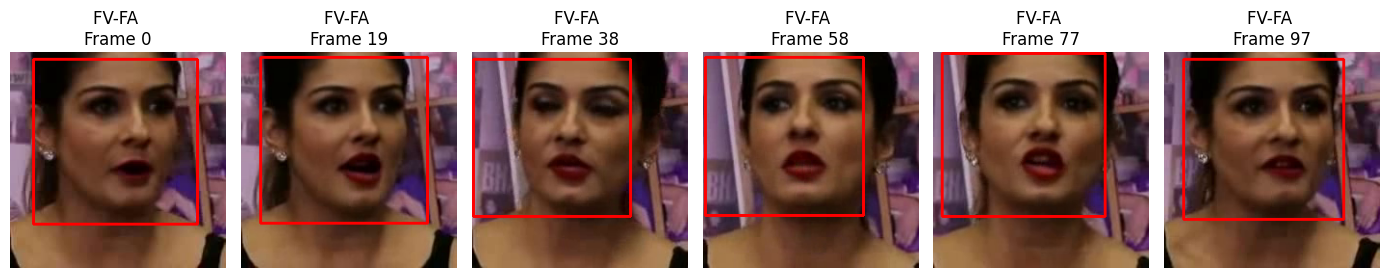

In [28]:
for label_id in [0, 1, 2, 3]:
    sample_video = train_df[train_df["label"] == label_id].iloc[0]["video_path"]
    show_lip_boxes(sample_video, LABEL_MAP[label_id])

In [29]:
"""
1. RV-RA (Real Video – Real Audio)
Lip box tightly fits mouth region
Smooth lip movement across frames
Natural shape changes


2. FV-RA (Fake Video – Real Audio)
Lip box is correct
Slight rigidity in motion
Subtle boundary jitter


3. RV-FA (Real Video – Fake Audio)
Lip movement is natural
Mismatch between audio and lip motion


4. FV-FA (Fake Video – Fake Audio)
Repetitive or unnatural lip motion
Less micro-expressions
Occasional box jitter
"""

'\n1. RV-RA (Real Video – Real Audio)\nLip box tightly fits mouth region\nSmooth lip movement across frames\nNatural shape changes\n\n\n2. FV-RA (Fake Video – Real Audio)\nLip box is correct\nSlight rigidity in motion\nSubtle boundary jitter\n\n\n3. RV-FA (Real Video – Fake Audio)\nLip movement is natural\nMismatch between audio and lip motion\n\n\n4. FV-FA (Fake Video – Fake Audio)\nRepetitive or unnatural lip motion\nLess micro-expressions\nOccasional box jitter\n'

STEP 6: CUSTOM DATASET & DATALOADER (AUDIO + VIDEO FUSION)

(mfcc, log_mel, lip_frames, label)

Shapes:

MFCC → (1, 40, 126)

Log-Mel → (1, 64, 126)

Frames → (16, 3, 112, 112)

Label → scalar (0–3)

6.1: Define Custom Dataset Class

In [30]:
from torch.utils.data import Dataset

class FakeAVDataset(Dataset):
    def __init__(self, df):
        self.video_paths = df["video_path"].tolist()
        self.labels = df["label"].tolist()

    def __len__(self):
        return len(self.video_paths)

    def __getitem__(self, idx):
        video_path = self.video_paths[idx]
        label = self.labels[idx]

        # ---- AUDIO ----
        waveform = load_audio_from_video(video_path)
        mfcc, logmel = extract_audio_features(waveform)

        # ---- VIDEO (LIPS) ----
        frames = extract_lip_frames(video_path)

        return mfcc, logmel, frames, torch.tensor(label, dtype=torch.long)


6.2: Create Dataset Objects

In [31]:
# Create train & test datasets
train_dataset = FakeAVDataset(train_df)
test_dataset  = FakeAVDataset(test_df)

print("Train samples:", len(train_dataset))
print("Test samples :", len(test_dataset))

Train samples: 15096
Test samples : 6470


6.3: Handle Class Imbalance

In [32]:
# Balanced sampler for training

import numpy as np
from torch.utils.data import WeightedRandomSampler

labels = np.array(train_df["label"])
class_counts = np.bincount(labels)

class_weights = 1.0 / class_counts
sample_weights = class_weights[labels]

sampler = WeightedRandomSampler(
    weights=sample_weights,
    num_samples=len(sample_weights),
    replacement=True
)

6.4: Create DataLoaders

In [33]:
from torch.utils.data import DataLoader  
BATCH_SIZE = 4
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    sampler=sampler,
    num_workers=0,
    pin_memory=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=False
)
print("DataLoaders created successfully")

DataLoaders created successfully


6.5: Check One Batch

In [34]:
from torch.utils.data import DataLoader
from tqdm import tqdm

# Temporary loader ONLY for sanity check
sanity_loader = DataLoader(
    train_dataset,
    batch_size=1,
    shuffle=False,
    num_workers=0
)

print("\nRunning ...\n")

sanity_iter = iter(sanity_loader)

for _ in tqdm(range(1), desc="Loading 1 sample", ncols=80):
    mfcc, logmel, frames, labels = next(sanity_iter)

print("\nSanity check completed successfully.\n")

print("MFCC shape     :", mfcc.shape)
print("Log-Mel shape  :", logmel.shape)
print("Frames shape   :", frames.shape)
print("Label          :", labels)


Running ...



Loading 1 sample: 100%|███████████████████████████| 1/1 [00:00<00:00,  1.89it/s]


Sanity check completed successfully.

MFCC shape     : torch.Size([1, 1, 40, 126])
Log-Mel shape  : torch.Size([1, 1, 64, 126])
Frames shape   : torch.Size([1, 16, 3, 112, 112])
Label          : tensor([3])


Step 7: Model Architecture

7.1: Audio Network (AudioNet)

In [35]:
# Audio Network

import torch.nn as nn

class AudioNet(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()

        def audio_cnn():
            return nn.Sequential(
                nn.Conv2d(1, 32, kernel_size=3, padding=1),
                nn.BatchNorm2d(32),
                nn.ReLU(),
                nn.MaxPool2d(2),
                nn.Conv2d(32, 64, kernel_size=3, padding=1),
                nn.BatchNorm2d(64),
                nn.ReLU(),
                nn.AdaptiveAvgPool2d((1, 1))
            )

        self.mfcc_net = audio_cnn()
        self.mel_net  = audio_cnn()

        self.fc = nn.Linear(64 * 2, emb_dim)

    def forward(self, mfcc, mel):
        mfcc_feat = self.mfcc_net(mfcc).squeeze()
        mel_feat  = self.mel_net(mel).squeeze()
        x = torch.cat([mfcc_feat, mel_feat], dim=1)
        return self.fc(x)


7.2: Video Network (VideoNet)

In [36]:
# Video Network

from torchvision import models

class VideoNet(nn.Module):
    def __init__(self, emb_dim=128):
        super().__init__()

        resnet = models.resnet18(
            weights=models.ResNet18_Weights.IMAGENET1K_V1
        )

        self.backbone = nn.Sequential(*list(resnet.children())[:-1])
        self.fc = nn.Linear(512, emb_dim)

    def forward(self, frames):
        B, T, C, H, W = frames.shape
        frames = frames.view(B * T, C, H, W)

        feats = self.backbone(frames)
        feats = feats.view(B, T, 512).mean(dim=1)

        return self.fc(feats)

7.3: Fusion Network (AVFusionNet)

In [37]:
# Audio-Video Fusion Network

class AVFusionNet(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()

        self.audio_net = AudioNet()
        self.video_net = VideoNet()

        self.fusion = nn.Sequential(
            nn.Linear(256, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, mfcc, mel, frames):
        audio_feat = self.audio_net(mfcc, mel)
        video_feat = self.video_net(frames)

        fused = torch.cat([audio_feat, video_feat], dim=1)
        return self.fusion(fused)

7.4: Model Initialization

In [38]:
model = AVFusionNet(num_classes=4).to(device)
print(model)

AVFusionNet(
  (audio_net): AudioNet(
    (mfcc_net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU()
      (7): AdaptiveAvgPool2d(output_size=(1, 1))
    )
    (mel_net): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (5): BatchNorm2d(64, eps=1e-05, momentum=

Step 8: TRAINING & VALIDATION LOOP

8.1: Loss Function & Optimizer

In [39]:
#Loss function & optimizer
"""
CrossEntropyLoss → multi-class classification
Class weights → handle any remaining imbalance
Adam optimizer → stable and fast convergence
"""

import torch.optim as optim
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

# Compute class weights from training labels
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2, 3]),
    y=train_df["label"].values
)

class_weights = torch.tensor(class_weights, dtype=torch.float32).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)
optimizer = optim.Adam(model.parameters(), lr=1e-4)
print("Loss and optimizer initialized")

Loss and optimizer initialized


8.2 : Train One Epoch with ETA

In [40]:
from tqdm import tqdm
import time

def train_one_epoch(model, loader, optimizer, criterion, device, epoch, epochs):
    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    start_time = time.time()

    progress = tqdm(
        loader,
        desc=f"Epoch [{epoch+1}/{epochs}] Training",
        ncols=120,
        unit="batch"
    )

    for mfcc, mel, frames, labels in progress:
        mfcc   = mfcc.to(device)
        mel    = mel.to(device)
        frames = frames.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        outputs = model(mfcc, mel, frames)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * labels.size(0)
        preds = outputs.argmax(dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

        # tqdm auto-updates ETA
        progress.set_postfix({
            "loss": f"{loss.item():.4f}",
            "acc": f"{(correct/total)*100:.2f}%"
        })

    epoch_time = (time.time() - start_time) / 60
    avg_loss = total_loss / total
    avg_acc = (correct / total) * 100

    return avg_loss, avg_acc, epoch_time

8.3 : Validation with ETA

In [41]:
def validate(model, loader, criterion, device, epoch, epochs):
    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    progress = tqdm(
        loader,
        desc=f"Epoch [{epoch+1}/{epochs}] Validation",
        ncols=120,
        unit="batch"
    )

    with torch.no_grad():
        for mfcc, mel, frames, labels in progress:
            mfcc   = mfcc.to(device)
            mel    = mel.to(device)
            frames = frames.to(device)
            labels = labels.to(device)

            outputs = model(mfcc, mel, frames)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

            progress.set_postfix({
                "val_acc": f"{(correct/total)*100:.2f}%"
            })

    avg_loss = total_loss / total
    avg_acc = (correct / total) * 100

    return avg_loss, avg_acc

8.4 : Full Training Loop with ETA

In [42]:
EPOCHS = 10
best_val_acc = 0.0
epoch_times = []

for epoch in range(EPOCHS):
    print(f"\n========== Epoch {epoch+1}/{EPOCHS} ==========")

    train_loss, train_acc, epoch_time = train_one_epoch(
        model, train_loader, optimizer, criterion, device, epoch, EPOCHS
    )

    val_loss, val_acc = validate(
        model, test_loader, criterion, device, epoch, EPOCHS
    )

    epoch_times.append(epoch_time)
    avg_epoch_time = sum(epoch_times) / len(epoch_times)
    remaining_time = avg_epoch_time * (EPOCHS - epoch - 1)

    print(f"\nTrain Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")
    print(f"Epoch Time: {epoch_time:.2f} min")
    print(f"Estimated Remaining Time: {remaining_time:.2f} min")

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), "new_best_big_av_model.pth")
        print(" Best model saved")


========== Epoch 1/10 ==========


Epoch [1/10] Validation: 100%|█████████████████████████████████| 1618/1618 [1:12:55<00:00,  2.70s/batch, val_acc=74.68%]



Train Loss: 0.7054 | Train Acc: 55.01%
Val   Loss: 0.6302 | Val   Acc: 74.68%
Epoch Time: 226.07 min
Estimated Remaining Time: 2034.62 min
 Best model saved

========== Epoch 2/10 ==========


Epoch [2/10] Validation: 100%|█████████████████████████████████| 1618/1618 [1:09:55<00:00,  2.59s/batch, val_acc=92.21%]



Train Loss: 0.4781 | Train Acc: 69.83%
Val   Loss: 0.3024 | Val   Acc: 92.21%
Epoch Time: 231.45 min
Estimated Remaining Time: 1830.08 min
 Best model saved

========== Epoch 3/10 ==========


...


Train Loss: 0.2310 | Train Acc: 87.70%
Val   Loss: 0.1825 | Val   Acc: 95.83%
Epoch Time: 186.39 min
Estimated Remaining Time: 417.58 min

========== Epoch 9/10 ==========


Epoch [9/10] Validation: 100%|█████████████████████████████████| 1618/1618 [1:02:19<00:00,  2.31s/batch, val_acc=95.30%]



Train Loss: 0.2284 | Train Acc: 87.83%
Val   Loss: 0.1920 | Val   Acc: 95.30%
Epoch Time: 180.64 min
Estimated Remaining Time: 205.66 min

========== Epoch 10/10 ==========


Epoch [10/10] Validation: 100%|████████████████████████████████| 1618/1618 [1:09:34<00:00,  2.58s/batch, val_acc=95.19%]


Train Loss: 0.1913 | Train Acc: 88.71%
Val   Loss: 0.1620 | Val   Acc: 95.19%
Epoch Time: 223.28 min
Estimated Remaining Time: 0.00 min


Step 9: TESTING, CONFUSION MATRIX

In [42]:
MODEL_PATH = "new_best_big_av_model.pth"

model.load_state_dict(torch.load(MODEL_PATH, map_location=device))
model.eval()

print("Loaded model:", MODEL_PATH)

C:\Users\LEGION\AppData\Local\Temp\ipykernel_23428\1526957914.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(MODEL_PATH, map_location=d

Loaded model: new_best_big_av_model.pth


In [43]:
# Testing loop

from tqdm import tqdm
import numpy as np

y_true = []
y_pred = []

with torch.no_grad():
    progress = tqdm(test_loader, desc="Testing", ncols=100)

    for mfcc, mel, frames, labels in progress:
        mfcc   = mfcc.to(device)
        mel    = mel.to(device)
        frames = frames.to(device)

        outputs = model(mfcc, mel, frames)
        preds = outputs.argmax(dim=1)

        y_true.extend(labels.numpy())
        y_pred.extend(preds.cpu().numpy())

Testing: 100%|████████████████████████████████████████████████| 1618/1618 [1:05:44<00:00,  2.44s/it]


In [44]:
# Accuracy
accuracy = np.mean(np.array(y_true) == np.array(y_pred)) * 100
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 98.04%


Confusion Matrix

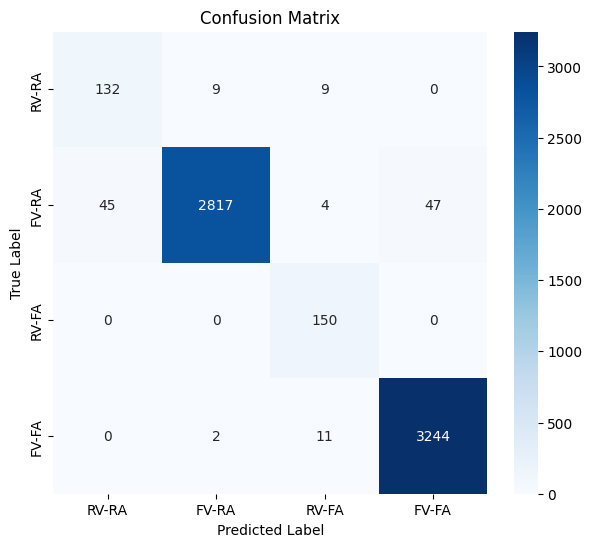


Classification Report:

              precision    recall  f1-score   support

      RV-RA        0.75      0.88      0.81       150
      FV-RA        1.00      0.97      0.98      2913
      RV-FA        0.86      1.00      0.93       150
      FV-FA        0.99      1.00      0.99      3257

    accuracy                           0.98      6470
   macro avg       0.90      0.96      0.93      6470
weighted avg       0.98      0.98      0.98      6470



In [45]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

import seaborn as sns
import matplotlib.pyplot as plt

LABEL_NAMES = [
    "RV-RA",
    "FV-RA",
    "RV-FA",
    "FV-FA"
]

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=LABEL_NAMES,
    yticklabels=LABEL_NAMES
)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


print("\nClassification Report:\n")
print(
    classification_report(
        y_true,
        y_pred,
        target_names=[
            "RV-RA ",
            "FV-RA ",
            "RV-FA ",
            "FV-FA "
        ]
    )
)